In [1]:
# In this case the local root of the repo is our working directory
DIRECTORY = '../../'
font = 'arial'




# We declare this function here and not in the
# function-storing python file to modify it easily
# as it can change the printouts of the methods
def printout(V, Stats, model): 
    # printing Stats
    print("R2 = %.2f (+/- %.2f) Constraint = %.2f (+/- %.2f)" % \
          (Stats.train_objective[0], Stats.train_objective[1],
           Stats.train_loss[0], Stats.train_loss[1]))
    Vout = tf.convert_to_tensor(np.float32(model.Y))
    Loss_norm, dLoss = Loss_Vout(V, model.Pout, Vout)
    print('Loss Targets', np.mean(Loss_norm))
    Loss_norm, dLoss = Loss_SV(V, model.S)
    print('Loss SV', np.mean(Loss_norm))
    Vin = tf.convert_to_tensor(np.float32(model.X))
    Pin = tf.convert_to_tensor(np.float32(model.Pin))
    if Vin.shape[1] == model.S.shape[1]: # special case
        Vin  = tf.linalg.matmul(Vin, tf.transpose(Pin), b_is_sparse=True)
    Loss_norm, dLoss = Loss_Vin(V, model.Pin, Vin, model.mediumbound,model)
    print('Loss Vin bound', np.mean(Loss_norm))
    Loss_norm, dLoss = Loss_Vpos(V, model)
    print('Loss V positive', np.mean(Loss_norm))

In [197]:
import sys
sys.path.insert(0, DIRECTORY)

from Lab_Notebooks.AMN.utils import load_experiment_data


per_strain = True
replication = "replicates"
strain = "SLAB"
experiment = "mediabotJLF1"
well_column = "wells"
gr_column = "mv_mu_max"

df_WT, df_exp_data_WT, df_levels_WT = load_experiment_data(per_strain=per_strain,
                                replication=replication,
                                strain=strain,
                                experiment=experiment,
                                well_column=well_column,
                                gr_column=gr_column)

# Mechanistic Models

# Examples with non-trainable mechanistic models, using FBA simulated training sets

In both LP and QP solver, one can change the `trainname` suffix (EB or UB) to use exact or upper bounds as inputs.

## LP solver

In [9]:
from pathlib import Path
import shutil
import numpy as np

import tensorflow as tf
from Library.Build_Model_lite_grads import Neural_Model, TrainingSet, MM_LP, write_loss, write_targets, r2_score, Loss_Vout, Loss_SV, Loss_Vin, Loss_Vpos, CROP, ReturnStats
# Run Mechanistic model (no training) QP (quadratic program) or LP (linear program)
# using E. coli core simulation training sets and EB (or UB) bounds

# What you can change
seed = 10
np.random.seed(seed=seed)  
replication = "no_replicates"
strain = "WT"
trainname = f'{strain}_UB_reduced_10' # the training set file name
size =  int(trainname.split('_')[-1]) # number of runs must be lower than the number of element in trainname
timestep =  100 # int(1.0e4) # LP 1.0e4 QP 1.0e5
learn_rate = 1e-3 # LP 0.3 QP 1.0
# End of What you can change

# Create model and run GD for X and Y randomly drawn from trainingfile
trainingfile = DIRECTORY+'Dataset_model/'+trainname

# Copy the model without size
# remove the size part if present
new_train_name = "_".join(trainname.split('_')[:-1])
trainingfile = './Dataset_model/'+new_train_name
# copy the model and paste with new name
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".npz", trainingfile + ".npz")
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".xml", trainingfile + ".xml")

print(f"Training file used: {trainingfile}")

biomass_reaction_name = 'BIOMASS_Ec_iML1515_core_75p37M'
# Get the target index for biomass reaction
original_parameter = TrainingSet()
original_parameter.load(trainingfile)
target_index = [r.id for r in original_parameter.model.reactions].index(biomass_reaction_name)
size = original_parameter.Y.shape[0]


model = Neural_Model(trainingfile = trainingfile, 
              objective=[biomass_reaction_name],#['BIOMASS_Ecoli_core_w_GAM'], 
              model_type = 'MM_LP', 
              timestep = timestep, 
              learn_rate = learn_rate,               
              verbose=True)
# from Library.Build_Model_lite_grads import MaxScaler
# model.X, s = MaxScaler(model.X)
# s

Training file used: ./Dataset_model/WT_UB_reduced
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\WT_UB_reduced_10.xml: True
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\WT_UB_reduced_10.xml: True
number of reactions:  635 635
number of metabolites:  1100
filtered measurements size:  1


In [10]:
model.printout()

training file: ./Dataset_model/WT_UB_reduced
model type: MM_LP
model scaler: 0.0
model input dim: 46
model output dim: 1
model medium bound: UB
timestep: 100
training set size (975, 46) (975, 1)


In [11]:


# Select a random subset of the training set (of specified size)
# With LP we also have to change b_ext and b_int accordingly
ID = np.random.choice(model.X.shape[0], size, replace=False)
model.X, model.Y = model.X[ID,:], model.Y[ID,:]
if model.mediumbound == 'UB':
    model.b_ext = model.b_ext[ID,:]
if model.mediumbound == 'EB':
    model.b_int = model.b_int[ID,:]

# Prints a summary of the model before running
model.printout()
# # Runs the appropriate method
Ypred, Stats, grad_history = MM_LP(model, verbose=True)
# # Printing results
printout(Ypred, Stats, model)
# Ypred = MM_LP(model, verbose=True, get_stats=False)



training file: ./Dataset_model/WT_UB_reduced
model type: MM_LP
model scaler: 0.0
model input dim: 46
model output dim: 1
model medium bound: UB
timestep: 100
training set size (975, 46) (975, 1)
LP-Loss 1 0.03891578 0.045427598 dV_norm: 48853.8828125
LP-Loss 10 6053.562 18.952808 dV_norm: 992392384.0


c:\Users\rh2310\projects\amn_release\.env\lib\site-packages\numpy\core\_methods.py:232: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
c:\Users\rh2310\projects\amn_release\.env\lib\site-packages\numpy\core\_methods.py:243: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


LP-Loss 100 nan nan dV_norm: nan
AMN output shapes for PoutV, SV, PinV, Vpos, V, outputs (975, 1) (975, 1) (975, 1) (975, 1) (975, 635) (975, 1274)


ValueError: Input contains NaN, infinity or a value too large for dtype('float32').

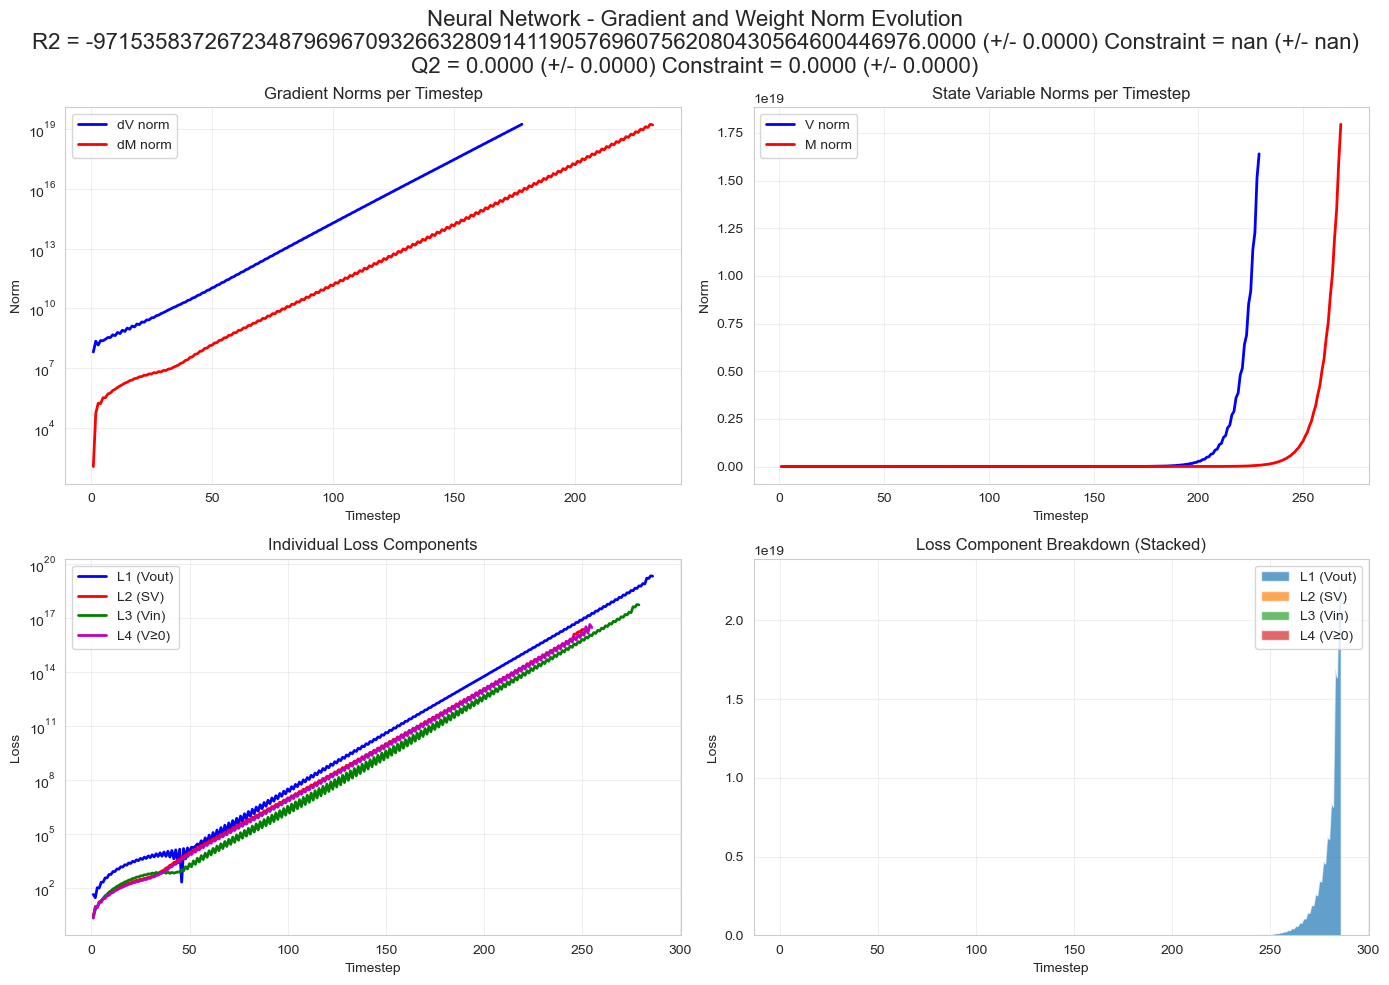

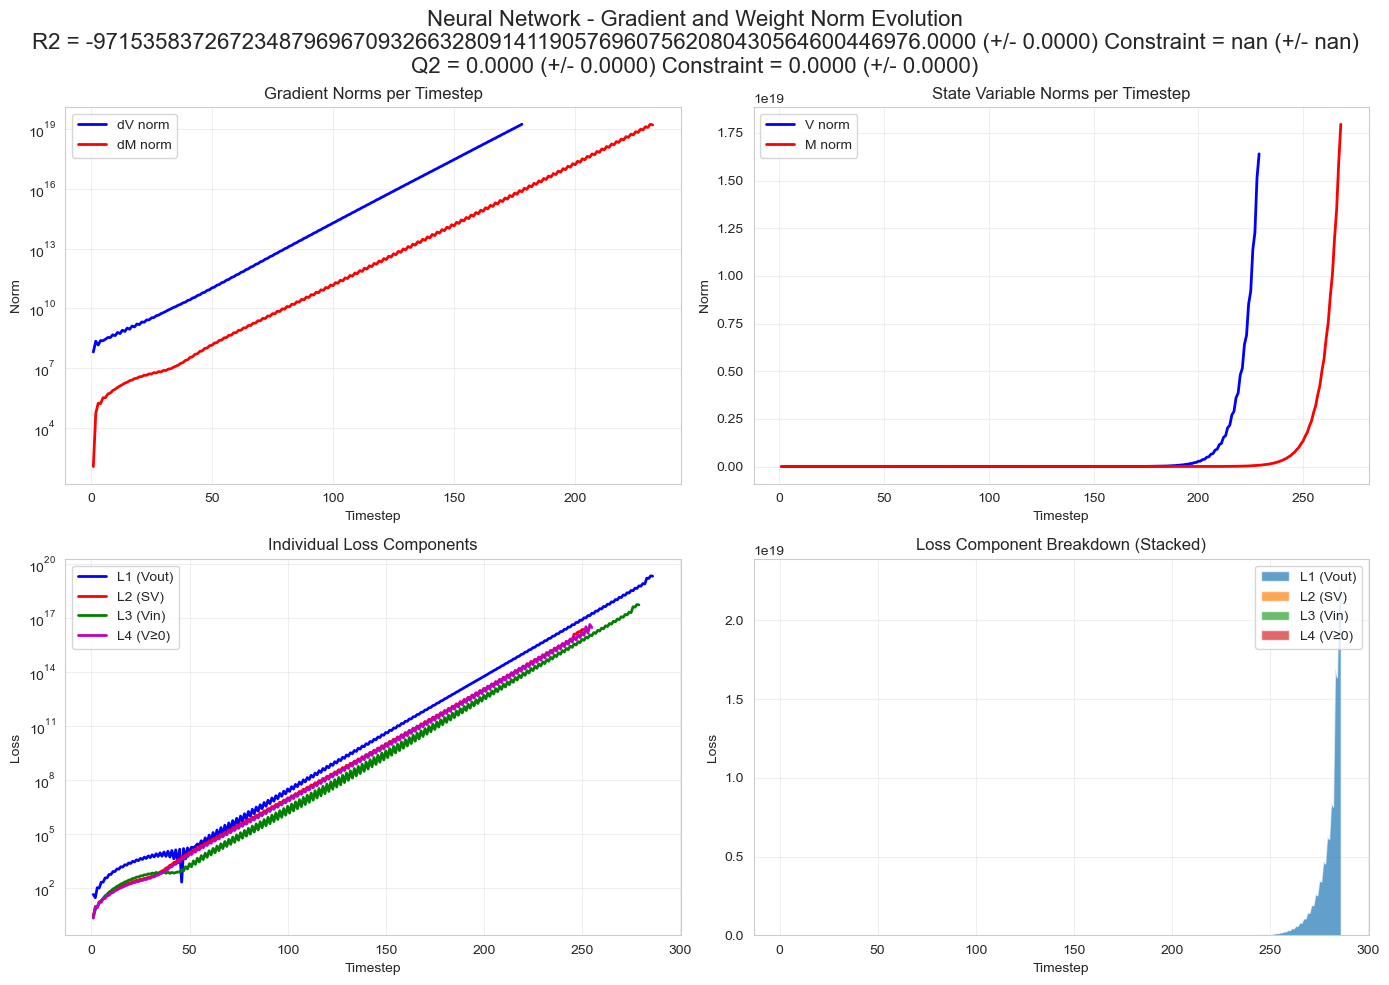

In [303]:
from Library.Build_Model_lite_grads import plot_mechanistic_gradients
plot_mechanistic_gradients(grad_history, 'LP', save_path=None, Stats=Stats)

In [263]:
from pathlib import Path
import shutil
import numpy as np

import tensorflow as tf
from Library.Build_Model_lite_grads import Neural_Model, TrainingSet, MM_LP, write_loss, write_targets, r2_score, Loss_Vout, Loss_SV, Loss_Vin, Loss_Vpos, CROP, ReturnStats
# Run Mechanistic model (no training) QP (quadratic program) or LP (linear program)
# using E. coli core simulation training sets and EB (or UB) bounds

# What you can change
seed = 10
np.random.seed(seed=seed)  
replication = "no_replicates"
strain = "WT"
trainname = f'{strain}_UB_reduced_10' # the training set file name
size =  int(trainname.split('_')[-1]) # number of runs must be lower than the number of element in trainname
timestep =  100 # int(1.0e4) # LP 1.0e4 QP 1.0e5
learn_rate = 0.001 # LP 0.3 QP 1.0
# End of What you can change

# Create model and run GD for X and Y randomly drawn from trainingfile
trainingfile = DIRECTORY+'Dataset_model/'+trainname

# Copy the model without size
# remove the size part if present
new_train_name = "_".join(trainname.split('_')[:-1])
trainingfile = './Dataset_model/'+new_train_name
# copy the model and paste with new name
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".npz", trainingfile + ".npz")
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".xml", trainingfile + ".xml")

print(f"Training file used: {trainingfile}")

biomass_reaction_name = 'BIOMASS_Ec_iML1515_core_75p37M'
# Get the target index for biomass reaction
original_parameter = TrainingSet()
original_parameter.load(trainingfile)
target_index = [r.id for r in original_parameter.model.reactions].index(biomass_reaction_name)
size = original_parameter.Y.shape[0]


model = Neural_Model(trainingfile = trainingfile, 
              objective=[biomass_reaction_name],#['BIOMASS_Ecoli_core_w_GAM'], 
              model_type = 'MM_LP', 
              timestep = timestep, 
              learn_rate = learn_rate, 
              verbose=True)

Training file used: ./Dataset_model/WT_UB_reduced
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\WT_UB_reduced_10.xml: True
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\WT_UB_reduced_10.xml: True
number of reactions:  622 622
number of metabolites:  1096
filtered measurements size:  1


In [ ]:
medium_columns = ['EX_ade_e', 'EX_ala__L_e', 'EX_arg__L_e', 'EX_asn__L_e', 'EX_asp__L_e',
       'EX_ca2_e', 'EX_cl_e', 'EX_cobalt2_e', 'EX_cu2_e', 'EX_cys__L_e',
       'EX_fe3_e', 'EX_gal_e', 'EX_glc__D_e', 'EX_gln__L_e', 'EX_glu__L_e',
       'EX_gly_e', 'EX_glyc_e', 'EX_h2o_e', 'EX_h_e', 'EX_his__L_e',
       'EX_ile__L_e', 'EX_k_e', 'EX_leu__L_e', 'EX_lys__L_e', 'EX_met__L_e',
       'EX_mg2_e', 'EX_mn2_e', 'EX_mobd_e', 'EX_na1_e', 'EX_nh4_e', 'EX_ni2_e',
       'EX_o2_e', 'EX_phe__L_e', 'EX_pi_e', 'EX_pro__L_e', 'EX_ser__L_e',
       'EX_so4_e', 'EX_succ_e', 'EX_sucr_e', 'EX_thr__L_e', 'EX_trp__L_e',
       'EX_tungs_e', 'EX_tyr__L_e', 'EX_ura_e', 'EX_val__L_e', 'EX_zn2_e']

In [293]:
df = pd.DataFrame(model.X, columns=medium_columns)
df_summary = df.describe()
df_summary

,EX_ade_e,EX_ala__L_e,EX_arg__L_e,EX_asn__L_e,EX_asp__L_e,EX_ca2_e,EX_cl_e,EX_cobalt2_e,EX_cu2_e,EX_cys__L_e,...,EX_so4_e,EX_succ_e,EX_sucr_e,EX_thr__L_e,EX_trp__L_e,EX_tungs_e,EX_tyr__L_e,EX_ura_e,EX_val__L_e,EX_zn2_e
count,980.000000,980.000000,980.000000,980.000000,980.000000,9.800000e+02,9.800000e+02,9.800000e+02,9.800000e+02,980.000000,...,9.800000e+02,980.000000,980.0,980.000000,980.000000,9.800000e+02,980.000000,980.000000,980.000000,9.800000e+02
mean,0.401451,0.045420,0.040023,0.026553,0.060862,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,0.062971,...,2.200000e+00,0.140748,0.0,0.068345,0.095918,2.200000e+00,0.078095,0.486349,0.058141,2.200000e+00
std,0.652132,0.255165,0.235981,0.210437,0.297627,4.443160e-16,4.443160e-16,4.443160e-16,4.443160e-16,0.312189,...,4.443160e-16,0.432054,0.0,0.307984,0.383127,4.443160e-16,0.331518,0.693468,0.295184,4.443160e-16
min,0.000000,0.000000,0.000000,0.000000,0.000000,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,0.000000,...,2.200000e+00,0.000000,0.0,0.000000,0.000000,2.200000e+00,0.000000,0.000000,0.000000,2.200000e+00
25%,0.000000,0.000000,0.000000,0.000000,0.000000,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,0.000000,...,2.200000e+00,0.000000,0.0,0.000000,0.000000,2.200000e+00,0.000000,0.000000,0.000000,2.200000e+00
50%,0.000000,0.000000,0.000000,0.000000,0.000000,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,0.000000,...,2.200000e+00,0.000000,0.0,0.000000,0.000000,2.200000e+00,0.000000,0.000000,0.000000,2.200000e+00
75%,0.733333,0.000000,0.000000,0.000000,0.000000,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,0.000000,...,2.200000e+00,0.000000,0.0,0.000000,0.000000,2.200000e+00,0.000000,0.961111,0.000000,2.200000e+00
max,2.200000,2.155556,2.177778,2.177778,2.177778,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.177778,...,2.200000e+00,2.200000,0.0,2.133333,2.177778,2.200000e+00,2.200000,2.200000,2.177778,2.200000e+00


2.2
[0.         1.15555556 1.31111111 0.82222222 2.11111111 1.37777778
 0.13333333 0.64444444 0.35555556 1.8        0.24444444 1.26666667
 1.86666667 1.11111111 1.35555556 0.75555556 1.53333333 0.66666667
 0.26666667 1.73333333 0.42222222 1.93333333 0.73333333 1.84444444
 1.64444444 0.53333333 0.2        1.06666667 2.08888889 1.33333333
 0.93333333 0.84444444 2.13333333 0.62222222 0.22222222 1.66666667
 1.17777778 1.57777778 1.62222222 0.11111111 2.04444444 1.08888889
 1.95555556 1.77777778 0.48888889 1.13333333 2.         0.37777778
 1.97777778 0.57777778 1.2        0.46666667 1.46666667 0.97777778
 1.75555556 0.95555556 1.82222222 0.04444444 0.51111111 1.88888889
 0.15555556 1.68888889 1.28888889 1.4        1.55555556 0.77777778
 2.06666667 0.33333333 0.8        2.15555556 1.24444444 1.22222222
 0.71111111 1.48888889 1.         1.44444444 1.04444444 1.02222222
 0.4        0.6        0.88888889 0.28888889 0.91111111 0.02222222
 1.42222222 0.08888889 2.17777778 0.44444444 2.02222222 1.

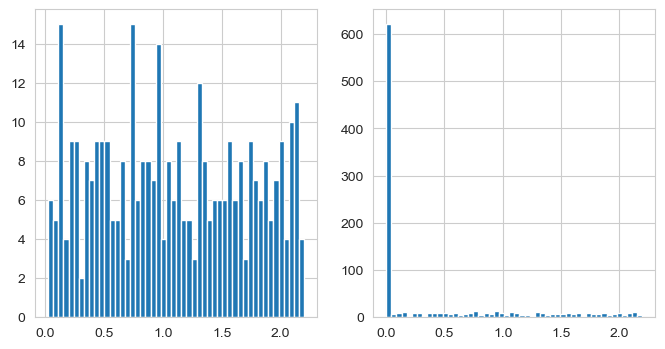

In [294]:
c = "EX_ade_e"
print(df[c].dropna().max())
print(df[c].dropna().unique())
f = plt.figure(figsize=(8,4))
ax1, ax2 = f.subplots(1,2)
ax1.hist(df[c].dropna()[df[c].dropna() > 0], bins=50)
ax2.hist(df[c].dropna(), bins=50)
# ax.set_xlim([0, df_WT["EX_tungs_e"].dropna().max()])
plt.show()


In [164]:
.0470655184822541/0.030773608, 2.9062615770391624/2.400824781



(1.5294117765539257, 1.2105263158057857)

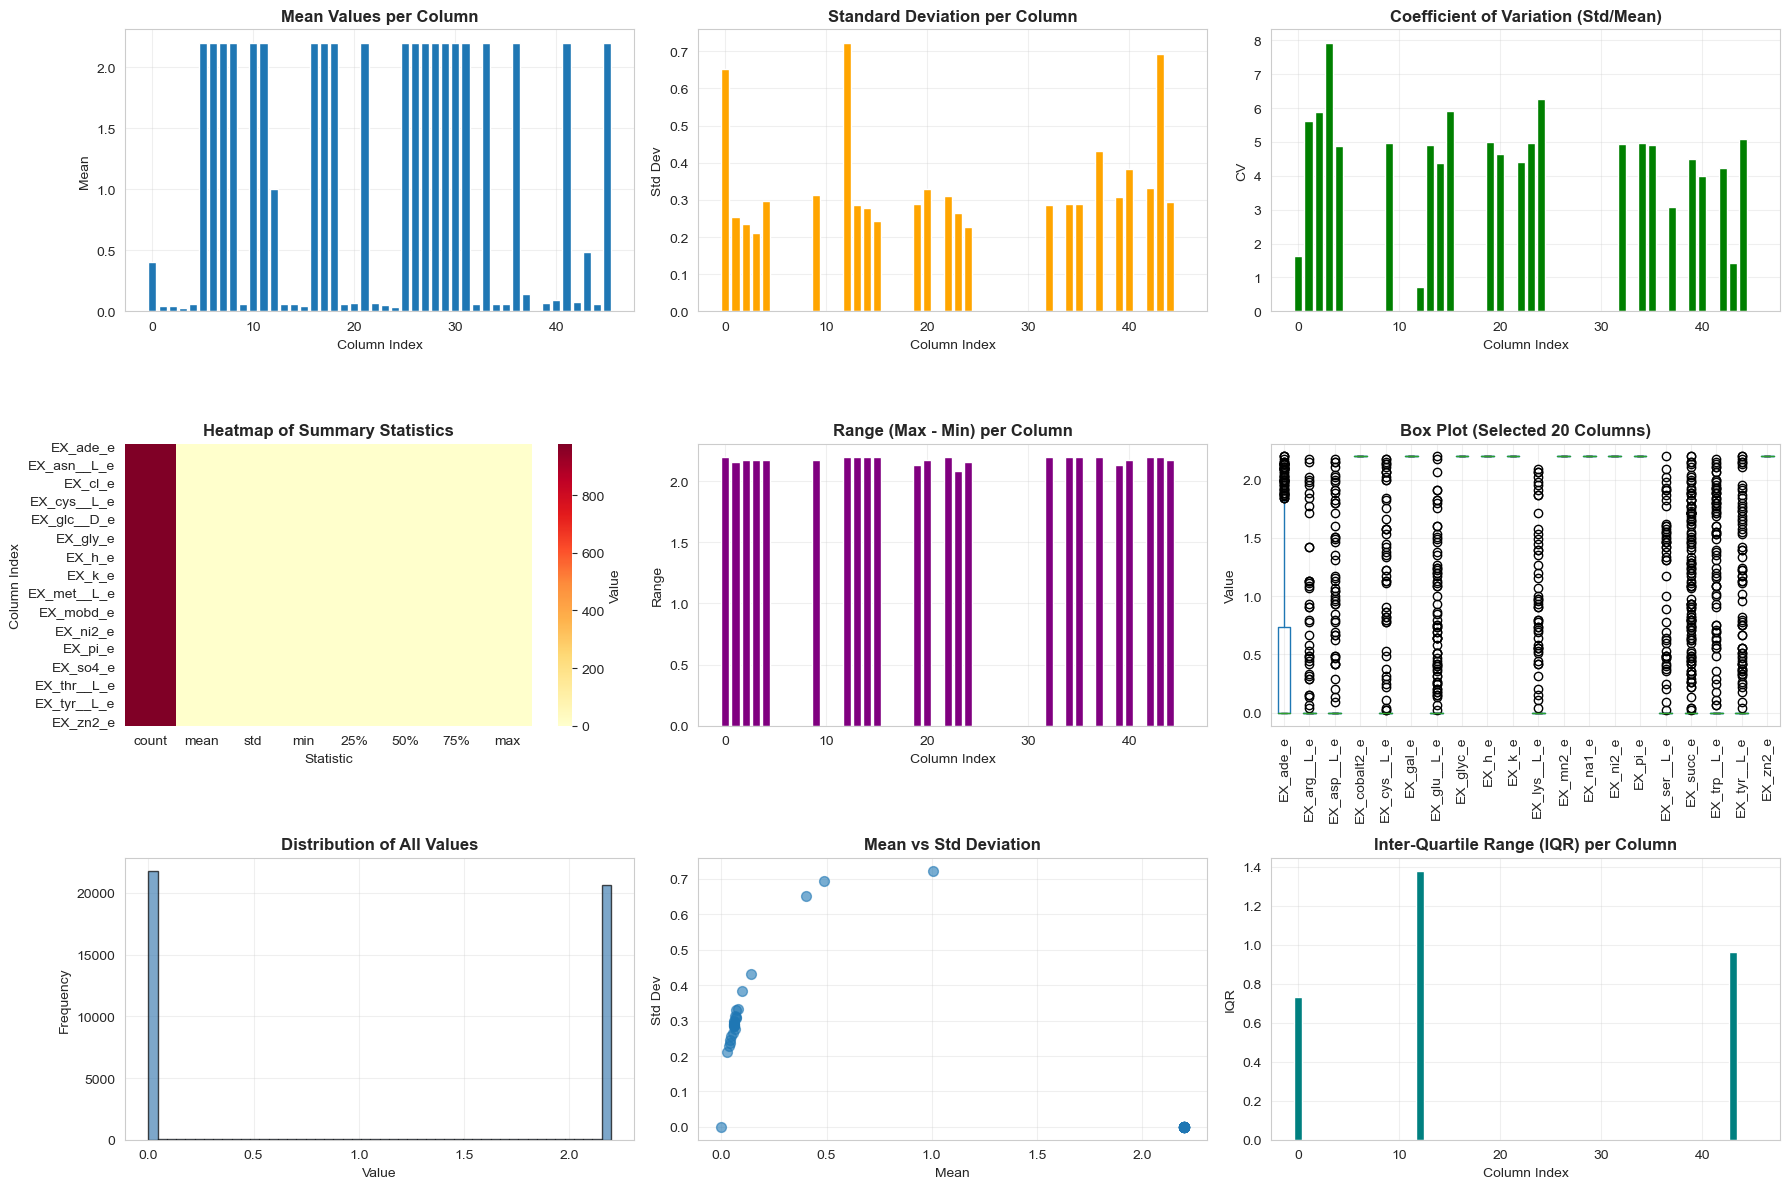

Dataset shape: (980, 46)
Total values: 45080
Missing values: 0


In [295]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create a comprehensive figure with multiple subplots
fig = plt.figure(figsize=(18, 12))

# 1. Bar plot of means across columns
ax1 = plt.subplot(3, 3, 1)
means = df.mean()
ax1.bar(range(len(means)), means.values)
ax1.set_title('Mean Values per Column', fontweight='bold')
ax1.set_xlabel('Column Index')
ax1.set_ylabel('Mean')
ax1.grid(True, alpha=0.3)

# 2. Bar plot of standard deviations
ax2 = plt.subplot(3, 3, 2)
stds = df.std()
ax2.bar(range(len(stds)), stds.values, color='orange')
ax2.set_title('Standard Deviation per Column', fontweight='bold')
ax2.set_xlabel('Column Index')
ax2.set_ylabel('Std Dev')
ax2.grid(True, alpha=0.3)

# 3. Coefficient of Variation (Std/Mean)
ax3 = plt.subplot(3, 3, 3)
cv = (stds / means).replace([np.inf, -np.inf], np.nan)
ax3.bar(range(len(cv)), cv.values, color='green')
ax3.set_title('Coefficient of Variation (Std/Mean)', fontweight='bold')
ax3.set_xlabel('Column Index')
ax3.set_ylabel('CV')
ax3.grid(True, alpha=0.3)

# 4. Heatmap of summary statistics
ax4 = plt.subplot(3, 3, 4)
sns.heatmap(df_summary.T, annot=False, cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Value'})
ax4.set_title('Heatmap of Summary Statistics', fontweight='bold')
ax4.set_xlabel('Statistic')
ax4.set_ylabel('Column Index')

# 5. Range (max - min) per column
ax5 = plt.subplot(3, 3, 5)
ranges = df.max() - df.min()
ax5.bar(range(len(ranges)), ranges.values, color='purple')
ax5.set_title('Range (Max - Min) per Column', fontweight='bold')
ax5.set_xlabel('Column Index')
ax5.set_ylabel('Range')
ax5.grid(True, alpha=0.3)

# 6. Box plot for selected columns (showing distributions)
ax6 = plt.subplot(3, 3, 6)
# Select subset of columns to avoid overcrowding
n_cols_to_show = min(20, len(df.columns))
cols_to_show = np.linspace(0, len(df.columns)-1, n_cols_to_show, dtype=int)
df.iloc[:, cols_to_show].boxplot(ax=ax6, rot=90)
ax6.set_title(f'Box Plot (Selected {n_cols_to_show} Columns)', fontweight='bold')
ax6.set_ylabel('Value')
ax6.grid(True, alpha=0.3)

# 7. Histogram of all values (flattened)
ax7 = plt.subplot(3, 3, 7)
ax7.hist(df.values.flatten(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax7.set_title('Distribution of All Values', fontweight='bold')
ax7.set_xlabel('Value')
ax7.set_ylabel('Frequency')
ax7.grid(True, alpha=0.3)

# 8. Mean vs Std scatter plot
ax8 = plt.subplot(3, 3, 8)
ax8.scatter(means.values, stds.values, alpha=0.6, s=50)
ax8.set_title('Mean vs Std Deviation', fontweight='bold')
ax8.set_xlabel('Mean')
ax8.set_ylabel('Std Dev')
ax8.grid(True, alpha=0.3)

# 9. Quartile ranges
ax9 = plt.subplot(3, 3, 9)
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)
iqr = q3 - q1
ax9.bar(range(len(iqr)), iqr.values, color='teal')
ax9.set_title('Inter-Quartile Range (IQR) per Column', fontweight='bold')
ax9.set_xlabel('Column Index')
ax9.set_ylabel('IQR')
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Dataset shape: {df.shape}")
print(f"Total values: {df.size}")
print(f"Missing values: {df.isnull().sum().sum()}")

In [ ]:
# Individual histograms for each column with statistics overlay
n_cols = len(df.columns)
n_cols_per_page = 20  # Show 20 columns per figure

# Calculate number of pages needed
n_pages = int(np.ceil(n_cols / n_cols_per_page))

for page in range(n_pages):
    start_idx = page * n_cols_per_page
    end_idx = min((page + 1) * n_cols_per_page, n_cols)
    cols_this_page = end_idx - start_idx
    
    # Create grid layout
    n_rows = int(np.ceil(cols_this_page / 5))
    fig, axes = plt.subplots(n_rows, 5, figsize=(20, 4*n_rows))
    axes = axes.flatten() if cols_this_page > 1 else [axes]
    
    for i, col_idx in enumerate(range(start_idx, end_idx)):
        ax = axes[i]
        col_data = df.iloc[:, col_idx]
        
        # Histogram
        ax.hist(col_data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        
        # Add vertical lines for mean and median
        mean_val = col_data.mean()
        median_val = col_data.median()
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean={mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median={median_val:.2f}')
        
        ax.set_title(f'Column {col_idx}\n(μ={mean_val:.2f}, σ={col_data.std():.2f})', fontsize=10)
        ax.set_xlabel('Value', fontsize=8)
        ax.set_ylabel('Frequency', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(cols_this_page, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'Column Histograms (Columns {start_idx}-{end_idx-1})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f"Displayed histograms for all {n_cols} columns across {n_pages} figure(s)")

In [ ]:
# Correlation analysis and column differences
fig = plt.figure(figsize=(18, 10))

# 1. Correlation heatmap (sample if too many columns)
ax1 = plt.subplot(2, 3, 1)
n_sample_cols = min(50, len(df.columns))
sample_cols = np.linspace(0, len(df.columns)-1, n_sample_cols, dtype=int)
corr_matrix = df.iloc[:, sample_cols].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, ax=ax1, 
            cbar_kws={'label': 'Correlation'}, square=True)
ax1.set_title(f'Correlation Matrix ({n_sample_cols} sampled columns)', fontweight='bold')

# 2. Distribution of correlation values
ax2 = plt.subplot(2, 3, 2)
# Get upper triangle of correlation matrix (exclude diagonal)
mask = np.triu(np.ones_like(corr_matrix), k=1).astype(bool)
corr_values = corr_matrix.where(mask).stack().values
ax2.hist(corr_values, bins=50, color='purple', edgecolor='black', alpha=0.7)
ax2.set_title('Distribution of Correlations', fontweight='bold')
ax2.set_xlabel('Correlation Coefficient')
ax2.set_ylabel('Frequency')
ax2.axvline(0, color='red', linestyle='--', linewidth=2)
ax2.grid(True, alpha=0.3)

# 3. Pairwise differences between consecutive columns
ax3 = plt.subplot(2, 3, 3)
if len(df.columns) > 1:
    diffs = []
    for i in range(len(df.columns) - 1):
        diff = np.abs(df.iloc[:, i+1] - df.iloc[:, i]).mean()
        diffs.append(diff)
    ax3.plot(diffs, marker='o', linestyle='-', linewidth=2, markersize=4)
    ax3.set_title('Mean Absolute Difference\n(Consecutive Columns)', fontweight='bold')
    ax3.set_xlabel('Column Index')
    ax3.set_ylabel('Mean |Diff|')
    ax3.grid(True, alpha=0.3)

# 4. Variance across columns
ax4 = plt.subplot(2, 3, 4)
variances = df.var()
ax4.plot(variances.values, color='darkgreen', linewidth=2)
ax4.fill_between(range(len(variances)), variances.values, alpha=0.3, color='green')
ax4.set_title('Variance per Column', fontweight='bold')
ax4.set_xlabel('Column Index')
ax4.set_ylabel('Variance')
ax4.grid(True, alpha=0.3)

# 5. Normalized columns (z-score) - mean across samples
ax5 = plt.subplot(2, 3, 5)
df_normalized = (df - df.mean()) / df.std()
sample_means = df_normalized.mean(axis=1)
ax5.hist(sample_means, bins=30, color='coral', edgecolor='black', alpha=0.7)
ax5.set_title('Distribution of Normalized Row Means', fontweight='bold')
ax5.set_xlabel('Z-Score Mean')
ax5.set_ylabel('Frequency')
ax5.axvline(0, color='red', linestyle='--', linewidth=2)
ax5.grid(True, alpha=0.3)

# 6. Skewness and Kurtosis
ax6 = plt.subplot(2, 3, 6)
from scipy.stats import skew, kurtosis
skewness = df.apply(lambda x: skew(x, nan_policy='omit'))
kurt = df.apply(lambda x: kurtosis(x, nan_policy='omit'))
ax6.scatter(skewness, kurt, alpha=0.6, s=50, c=range(len(df.columns)), cmap='viridis')
ax6.set_title('Skewness vs Kurtosis', fontweight='bold')
ax6.set_xlabel('Skewness')
ax6.set_ylabel('Kurtosis')
ax6.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax6.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax6.grid(True, alpha=0.3)
cbar = plt.colorbar(ax6.collections[0], ax=ax6)
cbar.set_label('Column Index')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nCorrelation Statistics:")
print(f"  Mean correlation: {corr_values.mean():.4f}")
print(f"  Max correlation: {corr_values.max():.4f}")
print(f"  Min correlation: {corr_values.min():.4f}")
print(f"\nDistribution Statistics:")
print(f"  Most skewed column: {skewness.abs().idxmax()} (skew={skewness[skewness.abs().idxmax()]:.4f})")
print(f"  Highest kurtosis: {kurt.idxmax()} (kurt={kurt.max():.4f})")

In [282]:
np.random.seed(seed=seed)  
trainname = 'iML1515_UB' # can change EB by UB
timestep = 4
# End of What you can change
  

# Create model and run GD for X and Y randomly drawn from trainingfile
trainingfile = DIRECTORY+'Dataset_model/'+trainname

# Copy the model without size
# remove the size part if present
# new_train_name = "_".join(trainname.split('_')[:-1])
# trainingfile = './Dataset_model/'+new_train_name
trainingfile = './Dataset_model/'+trainname
# copy the model and paste with new name
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".npz", trainingfile + ".npz")
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".xml", trainingfile + ".xml")

model = Neural_Model(trainingfile = trainingfile, 
                     objective=['BIOMASS_Ecoli_core_w_GAM'],  
                     model_type='AMN_Wt', 
                     timestep = timestep,
                     n_hidden = 1, hidden_dim = 50,
                     scaler=True,
                     train_rate=1e-2,
                     epochs=500, xfold=5,
                     verbose=True)

Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\Dataset_model\iML1515_UB.xml: True
number of reactions:  550 550
number of metabolites:  1083
filtered measurements size:  1


In [283]:
df2 = pd.DataFrame(model.X)
df2_summary = df2.describe()
df2_summary

,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
count,1.100000e+04,1.100000e+04,1.100000e+04,1.100000e+04,1.100000e+04,1.100000e+04,1.100000e+04,1.100000e+04,1.100000e+04,1.100000e+04,...,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000
mean,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,...,1.493913,1.209469,1.539705,1.534976,1.478238,1.482737,1.350937,1.356289,1.322636,1.524101
std,4.441094e-16,4.441094e-16,4.441094e-16,4.441094e-16,4.441094e-16,4.441094e-16,4.441094e-16,4.441094e-16,4.441094e-16,4.441094e-16,...,2.762198,2.546663,2.798591,2.813176,2.738321,2.725552,2.662128,2.658531,2.608954,2.743446
min,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,...,1.866667,0.222222,2.000000,1.955556,1.777778,1.866667,0.977778,1.077778,1.066667,2.044444
max,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,2.200000e+00,...,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000


In [ ]:
index = 200
print(df2[df2.columns[index]].dropna().max())
print(df2[df2.columns[index]].dropna().unique())
f = plt.figure(figsize=(8,4))
ax1, ax2 = f.subplots(1,2)
ax1.hist(df2[df2.columns[index]].dropna()[df2[df2.columns[index]].dropna() > 0], bins=50)
ax2.hist(df2[df2.columns[index]].dropna(), bins=50)
# ax.set_xlim([0, df_WT["EX_tungs_e"].dropna().max()])
plt.show()


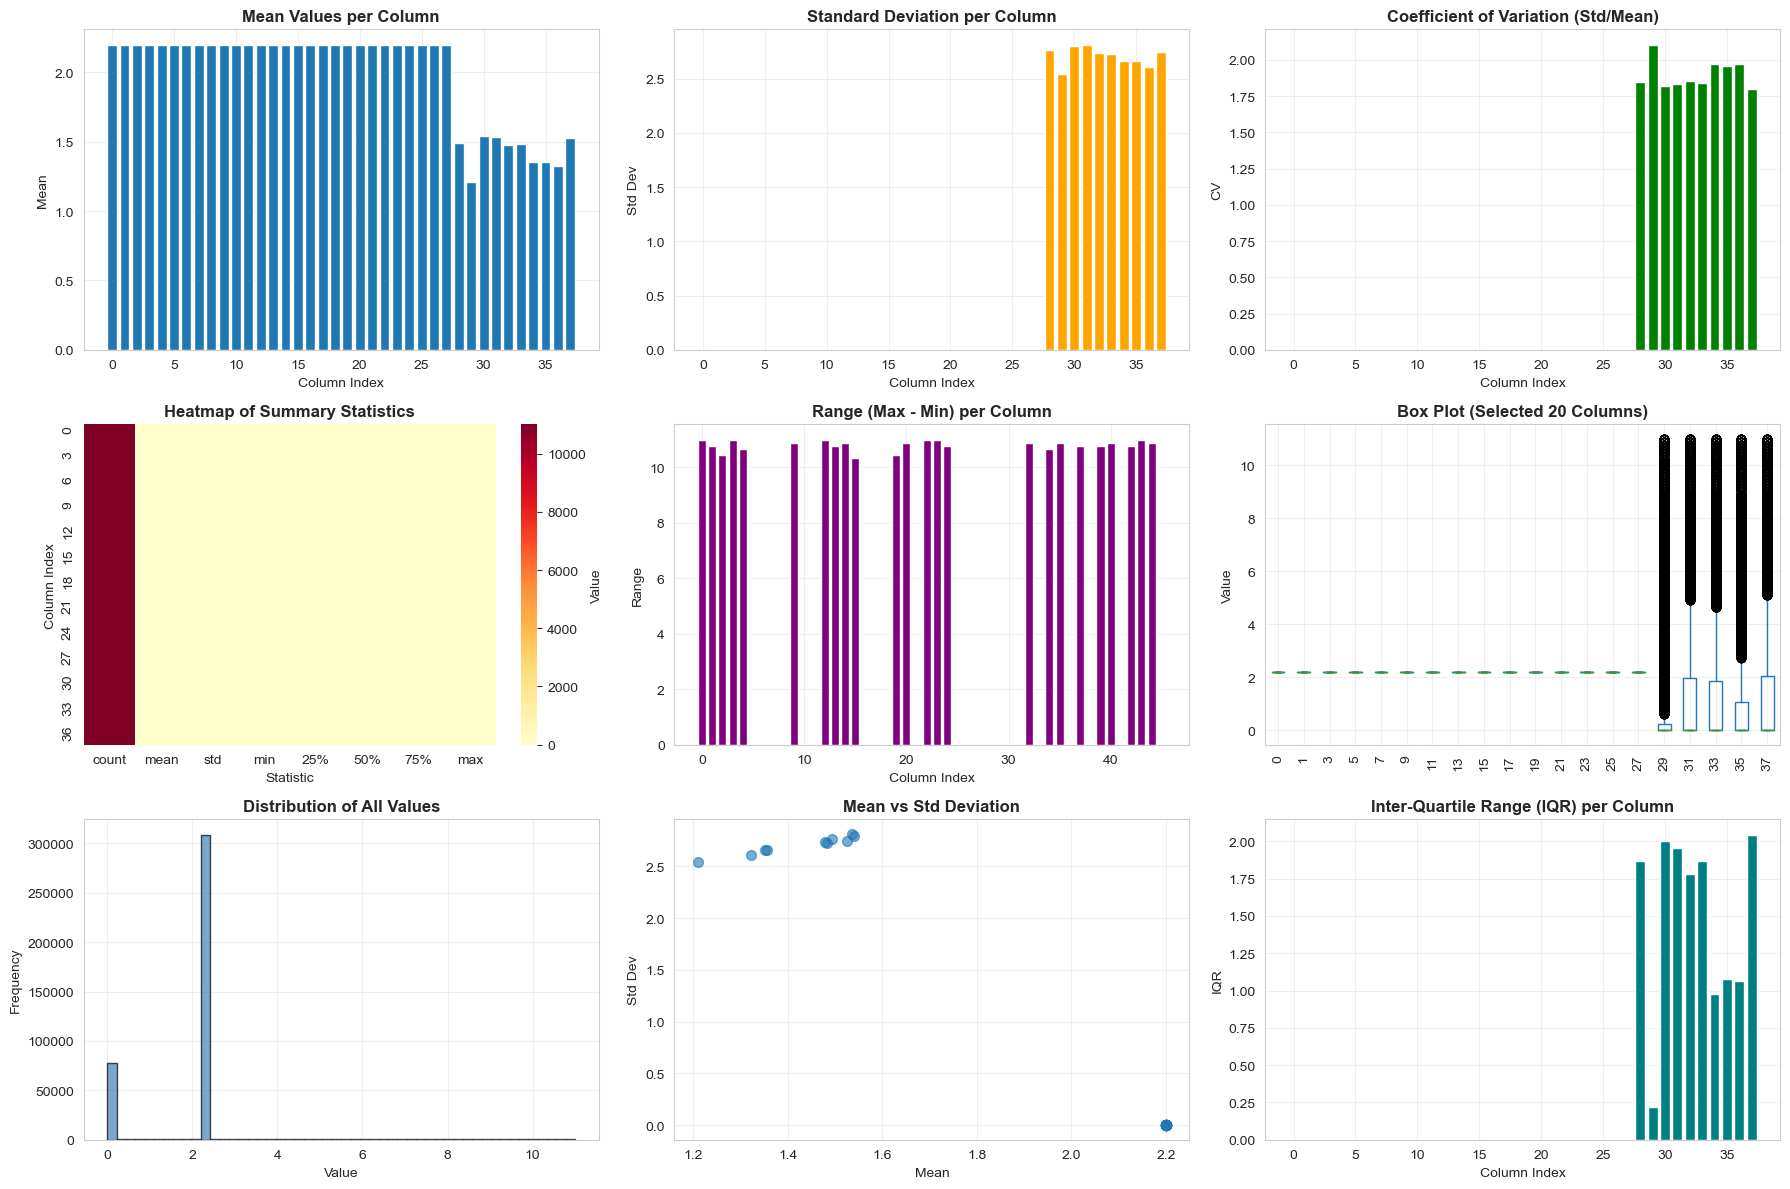

Dataset shape: (980, 46)
Total values: 45080
Missing values: 0


In [285]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create a comprehensive figure with multiple subplots
fig = plt.figure(figsize=(18, 12))

# 1. Bar plot of means across columns
ax1 = plt.subplot(3, 3, 1)
means = df2.mean()
ax1.bar(range(len(means)), means.values)
ax1.set_title('Mean Values per Column', fontweight='bold')
ax1.set_xlabel('Column Index')
ax1.set_ylabel('Mean')
ax1.grid(True, alpha=0.3)

# 2. Bar plot of standard deviations
ax2 = plt.subplot(3, 3, 2)
stds = df2.std()
ax2.bar(range(len(stds)), stds.values, color='orange')
ax2.set_title('Standard Deviation per Column', fontweight='bold')
ax2.set_xlabel('Column Index')
ax2.set_ylabel('Std Dev')
ax2.grid(True, alpha=0.3)

# 3. Coefficient of Variation (Std/Mean)
ax3 = plt.subplot(3, 3, 3)
cv = (stds / means).replace([np.inf, -np.inf], np.nan)
ax3.bar(range(len(cv)), cv.values, color='green')
ax3.set_title('Coefficient of Variation (Std/Mean)', fontweight='bold')
ax3.set_xlabel('Column Index')
ax3.set_ylabel('CV')
ax3.grid(True, alpha=0.3)

# 4. Heatmap of summary statistics
ax4 = plt.subplot(3, 3, 4)
sns.heatmap(df2_summary.T, annot=False, cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Value'})
ax4.set_title('Heatmap of Summary Statistics', fontweight='bold')
ax4.set_xlabel('Statistic')
ax4.set_ylabel('Column Index')

# 5. Range (max - min) per column
ax5 = plt.subplot(3, 3, 5)
ranges = df.max() - df.min()
ax5.bar(range(len(ranges)), ranges.values, color='purple')
ax5.set_title('Range (Max - Min) per Column', fontweight='bold')
ax5.set_xlabel('Column Index')
ax5.set_ylabel('Range')
ax5.grid(True, alpha=0.3)

# 6. Box plot for selected columns (showing distributions)
ax6 = plt.subplot(3, 3, 6)
# Select subset of columns to avoid overcrowding
n_cols_to_show = min(20, len(df2.columns))
cols_to_show = np.linspace(0, len(df2.columns)-1, n_cols_to_show, dtype=int)
df2.iloc[:, cols_to_show].boxplot(ax=ax6, rot=90)
ax6.set_title(f'Box Plot (Selected {n_cols_to_show} Columns)', fontweight='bold')
ax6.set_ylabel('Value')
ax6.grid(True, alpha=0.3)

# 7. Histogram of all values (flattened)
ax7 = plt.subplot(3, 3, 7)
ax7.hist(df2.values.flatten(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax7.set_title('Distribution of All Values', fontweight='bold')
ax7.set_xlabel('Value')
ax7.set_ylabel('Frequency')
ax7.grid(True, alpha=0.3)

# 8. Mean vs Std scatter plot
ax8 = plt.subplot(3, 3, 8)
ax8.scatter(means.values, stds.values, alpha=0.6, s=50)
ax8.set_title('Mean vs Std Deviation', fontweight='bold')
ax8.set_xlabel('Mean')
ax8.set_ylabel('Std Dev')
ax8.grid(True, alpha=0.3)

# 9. Quartile ranges
ax9 = plt.subplot(3, 3, 9)
q1 = df2.quantile(0.25)
q3 = df2.quantile(0.75)
iqr = q3 - q1
ax9.bar(range(len(iqr)), iqr.values, color='teal')
ax9.set_title('Inter-Quartile Range (IQR) per Column', fontweight='bold')
ax9.set_xlabel('Column Index')
ax9.set_ylabel('IQR')
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Dataset shape: {df.shape}")
print(f"Total values: {df.size}")
print(f"Missing values: {df.isnull().sum().sum()}")

In [14]:
original_parameter.model.reactions[63]

Reaction identifier,DHAD2
Name,"Dihydroxy-acid dehydratase (2,3-dihydroxy-3-methylpentanoate)"
Memory address,0x1b879ab9ec8
Stoichiometry,"23dhmp_c --> 3mop_c + h2o_c (R)-2,3-Dihydroxy-3-methylpentanoate --> (S)-3-Methyl-2-oxopentanoate + H2O H2O"
GPR,b3771
Lower bound,0.0
Upper bound,1000.0


In [14]:
Ypred.shape, Stats.test_loss, Stats.test_objective

((10, 154), (0, 0), (0, 0))

## QP solver

In [22]:
import shutil
import numpy as np
from Library.Build_Model_lite_grads import Neural_Model, TrainingSet, MM_QP

# Run Mechanistic model (no training) QP (quadratic program) or LP (linear program)
# using E. coli core simulation training sets and EB (or UB) bounds

# What you can change
seed = 10
np.random.seed(seed=seed)  
strain = "WT"
trainname = f'{strain}_UB_reduced_1' # the training set file name
size = int(trainname.split('_')[-1]) # number of runs must be lower than the number of element in trainname
timestep =  int(3.0e4) # LP 1.0e4 QP 1.0e5
learn_rate = 1.0 # LP 0.3 QP 1.0
decay_rate = 0.999 # only in QP, UB 0.333 EB 0.9
# End of What you can change

# Create model and run GD for X and Y randomly drawn from trainingfile
trainingfile = DIRECTORY+'Dataset_model/'+trainname

# Copy the model without size
# remove the size part if present
new_train_name = "_".join(trainname.split('_')[:-1])
trainingfile = './Dataset_model/'+new_train_name
# copy the model and paste with new name
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".npz", trainingfile + ".npz")
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".xml", trainingfile + ".xml")

print(f"Training file used: {trainingfile}")

biomass_reaction_name = 'BIOMASS_Ec_iML1515_core_75p37M'
# Get the target index for biomass reaction
original_parameter = TrainingSet()
original_parameter.load(trainingfile)
target_index = [r.id for r in original_parameter.model.reactions].index(biomass_reaction_name)
size = original_parameter.Y.shape[0]

model = Neural_Model(trainingfile = trainingfile, 
              objective=[biomass_reaction_name],#['BIOMASS_Ecoli_core_w_GAM'], 
              model_type = 'MM_QP', 
              timestep = timestep, 
              learn_rate = learn_rate, 
              decay_rate = decay_rate)

# Select a random subset of the training set (of specified size)
ID = np.random.choice(model.X.shape[0], size, replace=False)
model.X, model.Y = model.X[ID,:], model.Y[ID,:]

# Prints a summary of the model before running
model.printout()

# Runs the appropriate method
if model.model_type is 'MM_QP':
    Ypred, Stats, grad_history = MM_QP(model, verbose=True)

# Printing results
printout(Ypred, Stats, model)

Training file used: ./Dataset_model/WT_UB_reduced
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\WT_UB_reduced_1.xml: True
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\WT_UB_reduced_1.xml: True
training file: ./Dataset_model/WT_UB_reduced
model type: MM_QP
model scaler: 0.0
model input dim: 46
model output dim: 1
model medium bound: UB
timestep: 30000
training set size (98, 46) (98, 1)
QP-Loss 1 0.009006714 0.0060075866 GradNorm: 1.5280466079711914
QP-Loss 10 0.008772829 0.005783265 GradNorm: 1.4637678861618042
QP-Loss 100 0.003995756 0.0016094396 GradNorm: 0.6013758778572083
QP-Loss 1000 0.0021349434 0.0008781686 GradNorm: 0.4949629008769989
QP-Loss 2000 0.0014054447 0.00090373395 GradNorm: 0.5904706120491028
QP-Loss 3000 0.00026501573 0.000105670304 GradNorm: 0.14787091314792633
QP-Loss 4000 0.00021572158 0.00013637048 GradNorm: 0.22566275298595428
QP-Loss 5000 4.5283665e-05 1.4523958e-0

In [23]:
model.b_int.shape, model.b_ext.shape, model.Pout.shape, model.Pin.shape, model.S.shape, model.V2M.shape, model.model_type

((541,), (98, 2859), (1, 655), (46, 655), (1102, 655), (1102, 655), 'MM_QP')

In [34]:
exp_data.values[:,:-1].shape

(195, 46)

In [55]:
import pandas as pd
from matplotlib import pyplot as plt
import copy

replication = "no_replicates"

gr_column= "mv_mu_max"
exp_data_path = f"H:/ROBOT_SCIENTIST/E_coli/Growth_rates/2025-10-31-27/processed/{replication}_STRAINS/{strain}/AMN_dataset/"
exp_data = pd.read_csv(exp_data_path + "df_flux.csv")


model2  = copy.deepcopy(model)

model2.Y = exp_data[gr_column].values.reshape(-1,1)
model2.X = exp_data.values[:,:-1]#model2.X[:model2.Y.shape[0], :]

if model2.model_type is 'MM_QP':
    Ypred, Stats, _ = MM_QP(model2, verbose=True)

QP-Loss 1 0.018895146 0.009873535 GradNorm: 3.795797824859619
QP-Loss 10 0.018170657 0.009486426 GradNorm: 3.636122941970825
QP-Loss 100 0.003443686 0.0016190419 GradNorm: 1.4938677549362183
QP-Loss 1000 0.0021998733 0.0010550105 GradNorm: 1.2295292615890503
QP-Loss 2000 0.0028793018 0.0014943201 GradNorm: 1.4667795896530151
QP-Loss 3000 0.00022545768 0.00010252488 GradNorm: 0.3673233687877655
QP-Loss 4000 0.00042870443 0.00022000633 GradNorm: 0.5605652928352356
QP-Loss 5000 2.8250108e-05 9.192997e-06 GradNorm: 0.10266553610563278
QP-Loss 6000 7.102241e-05 3.3342763e-05 GradNorm: 0.21205353736877441
QP-Loss 7000 1.0282529e-05 1.8725651e-06 GradNorm: 0.025494370609521866
QP-Loss 8000 1.5585574e-05 5.442981e-06 GradNorm: 0.07944544404745102
QP-Loss 9000 6.456773e-06 1.0854776e-06 GradNorm: 0.004782565403729677
QP-Loss 10000 6.560729e-06 1.563375e-06 GradNorm: 0.02948872186243534
QP-Loss 11000 4.6091973e-06 8.7062324e-07 GradNorm: 5.6717417464824393e-05
QP-Loss 12000 4.0861323e-06 8.76912

In [51]:
model2.Y.shape, model2.X.shape, Ypred.shape, model2.Pout.shape

((195, 1), (195, 46), (195, 655), (1, 655))

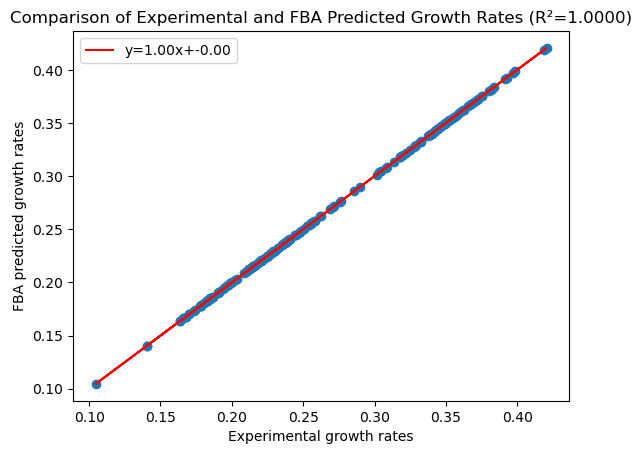

In [52]:
import pandas as pd
from matplotlib import pyplot as plt
replication = "no_replicates"

gr_column= "mv_mu_max"
targets = exp_data[gr_column].values.reshape(-1,1)

yhat = np.matmul(Ypred, model2.Pout.T)
plt.scatter(yhat, targets)
# regression line

y = np.array(targets).flatten()
x = np.array(yhat).flatten()
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', label=f'y={m:.2f}x+{b:.2f}')
# find R2
correlation_matrix = np.corrcoef(x, y)
correlation_xy = correlation_matrix[0,1]
r_squared = correlation_xy**2
plt.xlabel("Experimental growth rates")
plt.ylabel("FBA predicted growth rates")
plt.title(f"Comparison of Experimental and FBA Predicted Growth Rates (R²={r_squared:.4f})")
plt.legend()
plt.show()

In [243]:
np.random.seed(seed=seed)  
trainname = 'e_coli_core_UB_1000' #'biolog_iML1515_EXP_UB' # can change EB by UB

# End of What you can change
timestep =  10000 # int(1.0e4) # LP 1.0e4 QP 1.0e5
learn_rate = 3e-1 # LP 0.3 QP 1.0
# End of What you can change


biomass_reaction_name = 'BIOMASS_Ec_iML1515_core_75p37M'  

# Create model and run GD for X and Y randomly drawn from trainingfile
trainingfile = DIRECTORY+'Dataset_model/'+trainname

# Copy the model without size
# remove the size part if present
# new_train_name = "_".join(trainname.split('_')[:-1])
# trainingfile = './Dataset_model/'+new_train_name
trainingfile = './Dataset_model/'+trainname
# copy the model and paste with new name
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".npz", trainingfile + ".npz")
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".xml", trainingfile + ".xml")

model = Neural_Model(trainingfile = trainingfile, 
              objective=[biomass_reaction_name],#['BIOMASS_Ecoli_core_w_GAM'], 
              model_type = 'MM_LP', 
              timestep = timestep, 
              learn_rate = learn_rate, 
              verbose=True)

Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\Dataset_model\e_coli_core_UB_1000.xml: True
number of reactions:  154 154
number of metabolites:  72
filtered measurements size:  1


In [244]:
# Select a random subset of the training set (of specified size)
# With LP we also have to change b_ext and b_int accordingly
ID = np.random.choice(model.X.shape[0], size, replace=False)
model.X, model.Y = model.X[ID,:], model.Y[ID,:]
if model.mediumbound == 'UB':
    model.b_ext = model.b_ext[ID,:]
if model.mediumbound == 'EB':
    model.b_int = model.b_int[ID,:]

# Prints a summary of the model before running
model.printout()
# # Runs the appropriate method
Ypred, Stats, grad_history = MM_LP(model, verbose=True)
# # Printing results
printout(Ypred, Stats, model)

training file: ./Dataset_model/e_coli_core_UB_1000
model type: MM_LP
model scaler: 0.0
model input dim: 20
model output dim: 1
model medium bound: UB
timestep: 10000
training set size (980, 20) (980, 1)
LP-Loss 1 0.048222538 0.0059799515 dV_norm: 711.3814697265625
LP-Loss 10 0.0043997695 0.000648153 dV_norm: 72.33170318603516
LP-Loss 100 1.1958724e-05 1.8148388e-05 dV_norm: 37.601463317871094
LP-Loss 1000 0.16479637 0.037265502 dV_norm: 5.0967864990234375
LP-Loss 2000 0.16425598 0.037831116 dV_norm: 1.4430570602416992
LP-Loss 3000 0.16436076 0.037827622 dV_norm: 0.9848949909210205
LP-Loss 4000 0.16438356 0.03786135 dV_norm: 0.6825906038284302
LP-Loss 5000 0.16445631 0.037787747 dV_norm: 0.506233274936676
LP-Loss 6000 0.16440573 0.0378504 dV_norm: 0.3600192666053772
LP-Loss 7000 0.1643764 0.0378356 dV_norm: 0.2975614666938782
LP-Loss 8000 0.16444546 0.037793282 dV_norm: 0.2585431635379791
LP-Loss 9000 0.16442938 0.037803706 dV_norm: 0.23090685904026031
LP-Loss 10000 0.16437279 0.0378102

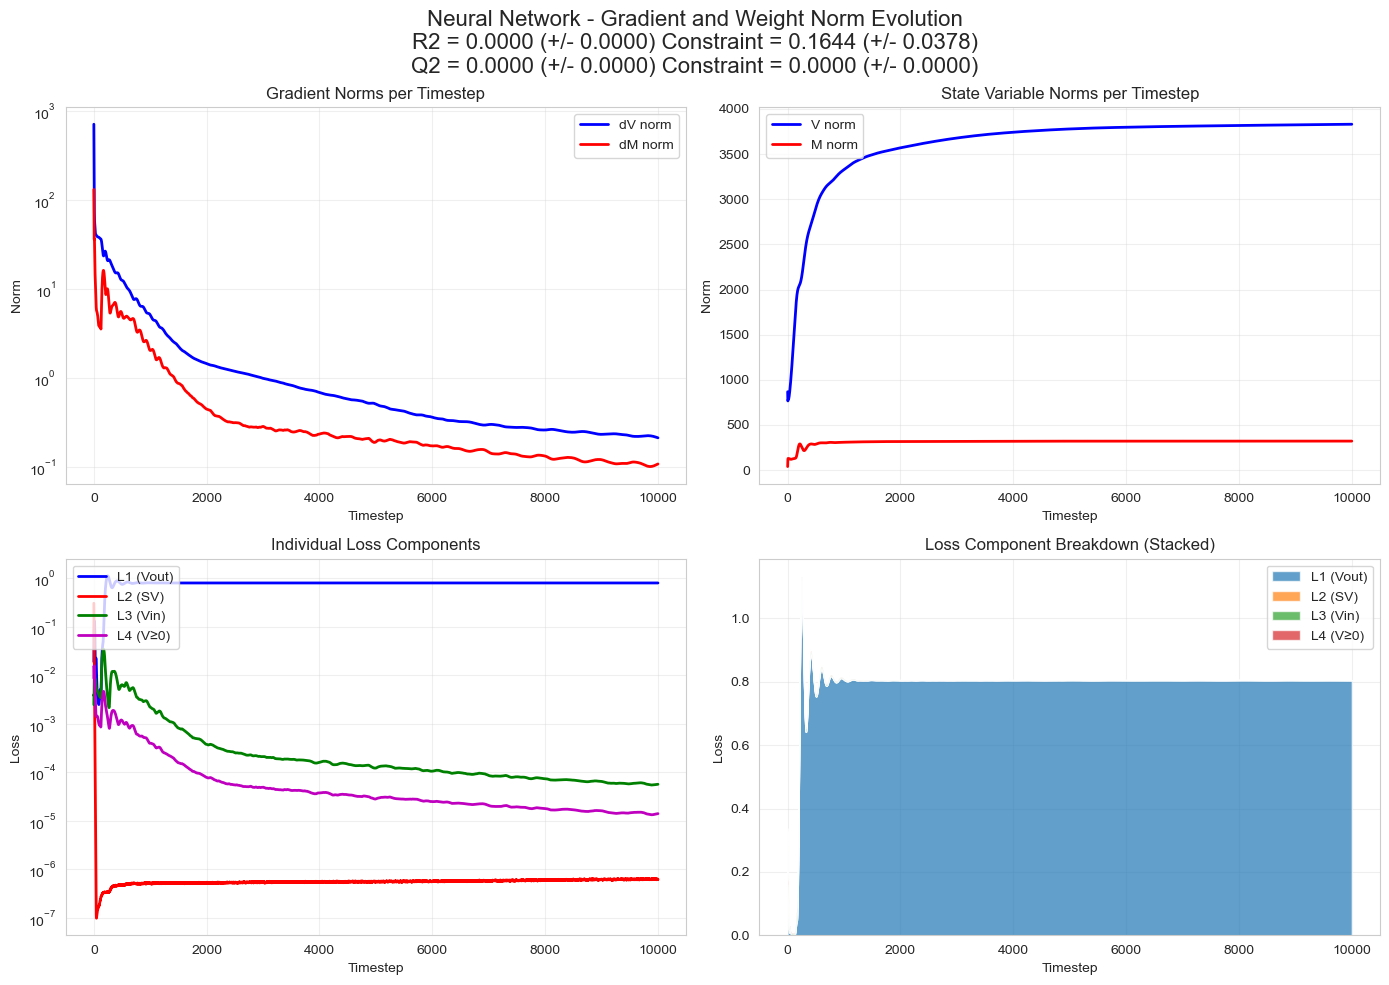

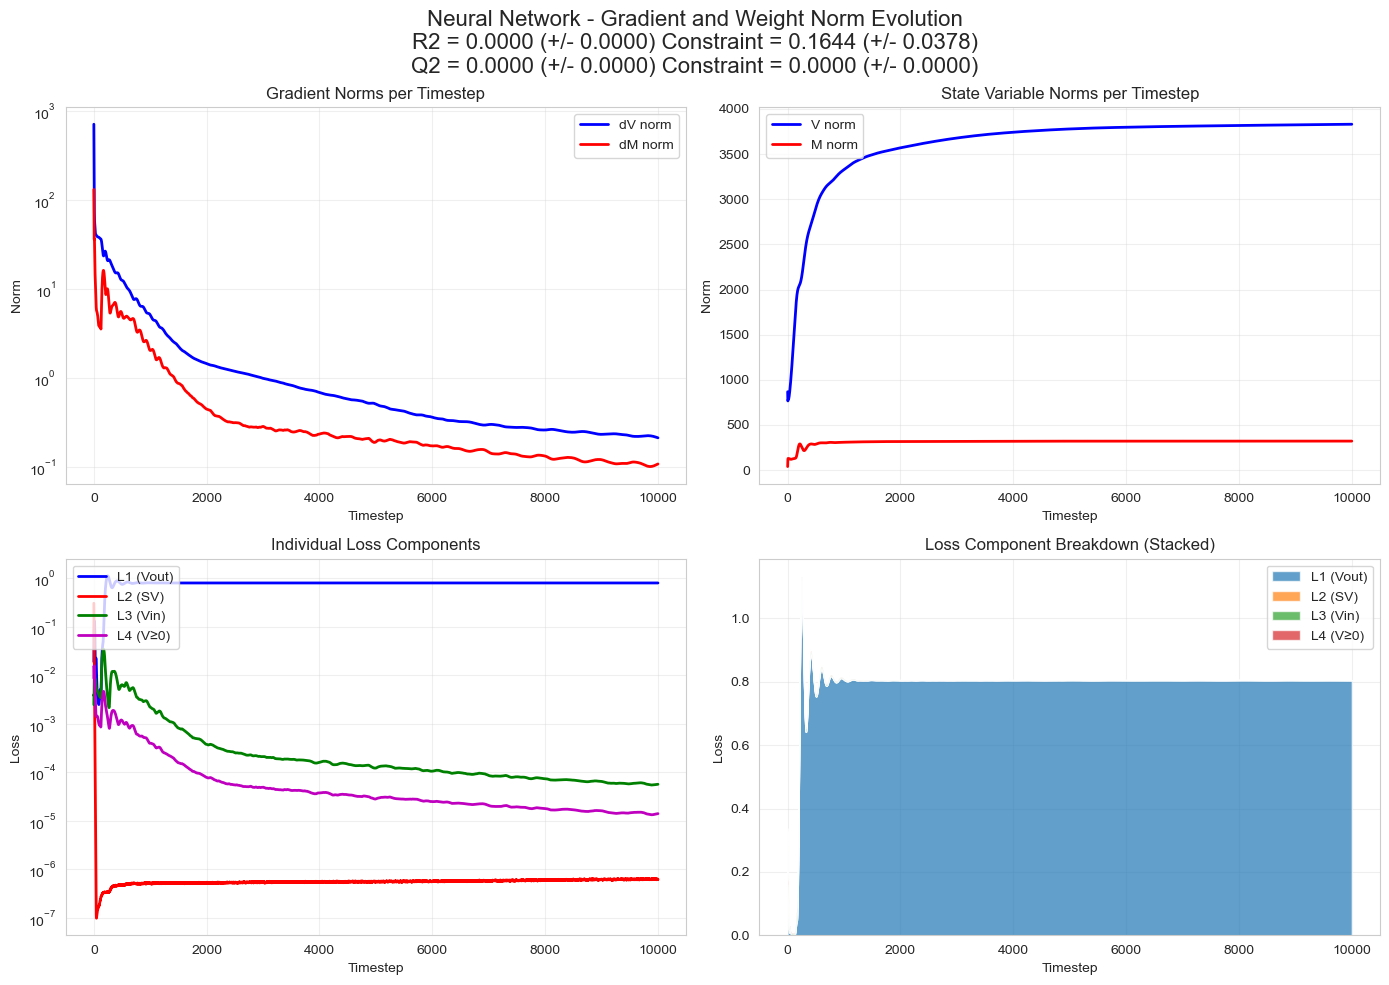

In [245]:
from Library.Build_Model_lite_grads import plot_mechanistic_gradients
plot_mechanistic_gradients(grad_history, 'LP', save_path=None, Stats=Stats)

In [246]:
df2 = pd.DataFrame(model.X)
df2_summary = df2.describe()
df2_summary

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
count,980.0,980.0,980.0,980.0,980.0,980.0,980.0,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000,980.000000
mean,10.0,10.0,10.0,10.0,10.0,10.0,10.0,3.063776,3.158163,2.836735,2.987245,3.040816,3.255102,3.150510,3.079082,3.234694,3.125000,3.201531,2.989796,2.987245
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.695477,3.728939,3.582371,3.689090,3.654634,3.653286,3.753317,3.667086,3.753925,3.714937,3.694328,3.621508,3.647321
min,10.0,10.0,10.0,10.0,10.0,10.0,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.0,10.0,10.0,10.0,10.0,10.0,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,10.0,10.0,10.0,10.0,10.0,10.0,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.500000,0.000000,0.000000,2.500000,2.500000,2.500000,0.000000,0.000000
75%,10.0,10.0,10.0,10.0,10.0,10.0,10.0,7.500000,7.500000,5.000000,5.000000,5.000000,7.500000,7.500000,7.500000,7.500000,5.000000,7.500000,5.000000,5.000000
max,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [266]:
df_summary

,EX_ade_e,EX_ala__L_e,EX_arg__L_e,EX_asn__L_e,EX_asp__L_e,EX_ca2_e,EX_cl_e,EX_cobalt2_e,EX_cu2_e,EX_cys__L_e,...,EX_so4_e,EX_succ_e,EX_sucr_e,EX_thr__L_e,EX_trp__L_e,EX_tungs_e,EX_tyr__L_e,EX_ura_e,EX_val__L_e,EX_zn2_e
count,980.000000,980.000000,980.000000,980.000000,980.000000,9.800000e+02,9.800000e+02,980.000000,9.800000e+02,980.000000,...,9.800000e+02,980.000000,980.0,980.000000,980.000000,980.0,980.000000,980.000000,980.000000,9.800000e+02
mean,0.020594,0.003778,0.028237,0.000985,0.002996,2.608696e-02,2.400825e+00,0.000067,1.035067e-04,0.001472,...,8.705353e-02,0.430612,0.0,0.004257,0.001500,20.0,0.002832,0.470002,0.003646,5.359023e-04
std,0.033640,0.022108,0.157644,0.008230,0.014920,3.471218e-18,4.443160e-16,0.000000,2.711889e-20,0.007600,...,1.388487e-17,1.370890,0.0,0.019747,0.006402,0.0,0.011933,0.705342,0.017728,1.084756e-19
min,0.000000,0.000000,0.000000,0.000000,0.000000,2.608696e-02,2.400825e+00,0.000067,1.035067e-04,0.000000,...,8.705353e-02,0.000000,0.0,0.000000,0.000000,20.0,0.000000,0.000000,0.000000,5.359023e-04
25%,0.000000,0.000000,0.000000,0.000000,0.000000,2.608696e-02,2.400825e+00,0.000067,1.035067e-04,0.000000,...,8.705353e-02,0.000000,0.0,0.000000,0.000000,20.0,0.000000,0.000000,0.000000,5.359023e-04
50%,0.000000,0.000000,0.000000,0.000000,0.000000,2.608696e-02,2.400825e+00,0.000067,1.035067e-04,0.000000,...,8.705353e-02,0.000000,0.0,0.000000,0.000000,20.0,0.000000,0.000000,0.000000,5.359023e-04
75%,0.033787,0.000000,0.000000,0.000000,0.000000,2.608696e-02,2.400825e+00,0.000067,1.035067e-04,0.000000,...,8.705353e-02,0.000000,0.0,0.000000,0.000000,20.0,0.000000,0.855075,0.000000,5.359023e-04
max,0.118404,0.206950,1.536492,0.101239,0.119898,2.608696e-02,2.400825e+00,0.000067,1.035067e-04,0.061882,...,8.705353e-02,8.405357,0.0,0.159839,0.041622,20.0,0.083246,2.482477,0.144543,5.359023e-04
